# IMAU-FDM Research Visualizations

Maps and time series of surface melt, runoff, and SMB from the
`run_FGRN055-era055_1939-2023` simulation, plus zone-transition analysis.

**Sections**
1. Setup
2. Annual maps — surfmelt, runoff, SMB
3. Point time series
4. Zone transition maps

## 1  Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, str(Path('.').resolve()))
import config
from zone_transition import (
    classify_zone_transitions,
    plot_zone_transitions,
    plot_zone_transition_panel,
)

plt.rcParams['figure.figsize'] = (9, 11)
plt.rcParams['font.size'] = 11
print('Config loaded. PROCESSED_DIR:', config.PROCESSED_DIR)

Config loaded. PROCESSED_DIR: /home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process


In [2]:
# Re-run this cell after editing zone_transition.py to reload on NFS
import importlib, zone_transition as _zt
importlib.reload(_zt)
from zone_transition import classify_zone_transitions, plot_zone_transitions
print('zone_transition.py reloaded.')

zone_transition.py reloaded.


### Helper functions

In [3]:
def load_annual(var_name, year, stat='sum'):
    """
    Load annual aggregate for a gridded variable.

    Parameters
    ----------
    var_name : str  — key in config.VARIABLE_FILES
    year     : int  — calendar year
    stat     : 'sum' (mm w.e. totals) or 'mean' (rate variables like vacc)

    Returns
    -------
    xr.DataArray  (rlat, rlon)
    """
    ds = xr.open_dataset(config.VARIABLE_FILES[var_name], decode_times=False)
    da = ds[var_name].sel(time=slice(year, year + 1))
    out = da.sum(dim='time') if stat == 'sum' else da.mean(dim='time')
    ds.close()
    return out


def compute_annual_smb(year):
    """
    Annual surface mass balance [mm w.e.] = vacc*1000 - Runoff.

    vacc is in m/yr; annual mean × 1000 converts to mm w.e./yr.
    Runoff is in mm w.e.; annual sum gives mm w.e./yr.
    Pixels off-ice (vacc=NaN) are returned as NaN.
    """
    accum  = load_annual('vacc',   year, stat='mean') * 1000.0  # mm w.e./yr
    runoff = load_annual('Runoff', year, stat='sum')             # mm w.e./yr
    smb = accum - runoff
    smb.attrs['long_name'] = f'Annual SMB ({year})'
    smb.attrs['units']     = 'mm w.e. yr⁻¹'
    return smb


def plot_annual_map(da, title='', cmap='viridis', vmin=None, vmax=None,
                    ax=None, colorbar_label=''):
    """
    Plot a 2-D DataArray on the rlat/rlon grid.

    Returns
    -------
    ax
    """
    if ax is None:
        _, ax = plt.subplots()
    im = da.plot(
        ax=ax, cmap=cmap,
        vmin=vmin, vmax=vmax,
        add_colorbar=True,
        cbar_kwargs=dict(label=colorbar_label, shrink=0.7, aspect=20, pad=0.02),
    )
    ax.set_aspect('equal')
    ax.set_xlabel('rlon (grid index)')
    ax.set_ylabel('rlat (grid index)')
    ax.set_title(title)
    return ax


def load_timeseries(var_name, rlat, rlon):
    """
    Extract a time series at a single grid point.

    Parameters
    ----------
    var_name : str  — key in config.VARIABLE_FILES
    rlat, rlon : int  — grid indices

    Returns
    -------
    xr.DataArray  (time,)
    """
    ds = xr.open_dataset(config.VARIABLE_FILES[var_name], decode_times=False)
    ts = ds[var_name].isel(rlat=rlat, rlon=rlon)
    ds.close()
    return ts


print('Helper functions defined.')

Helper functions defined.


---
## 2  Annual maps

Set `YEAR` below to choose which year to plot.

In [4]:
YEAR = 2012   # ← change this

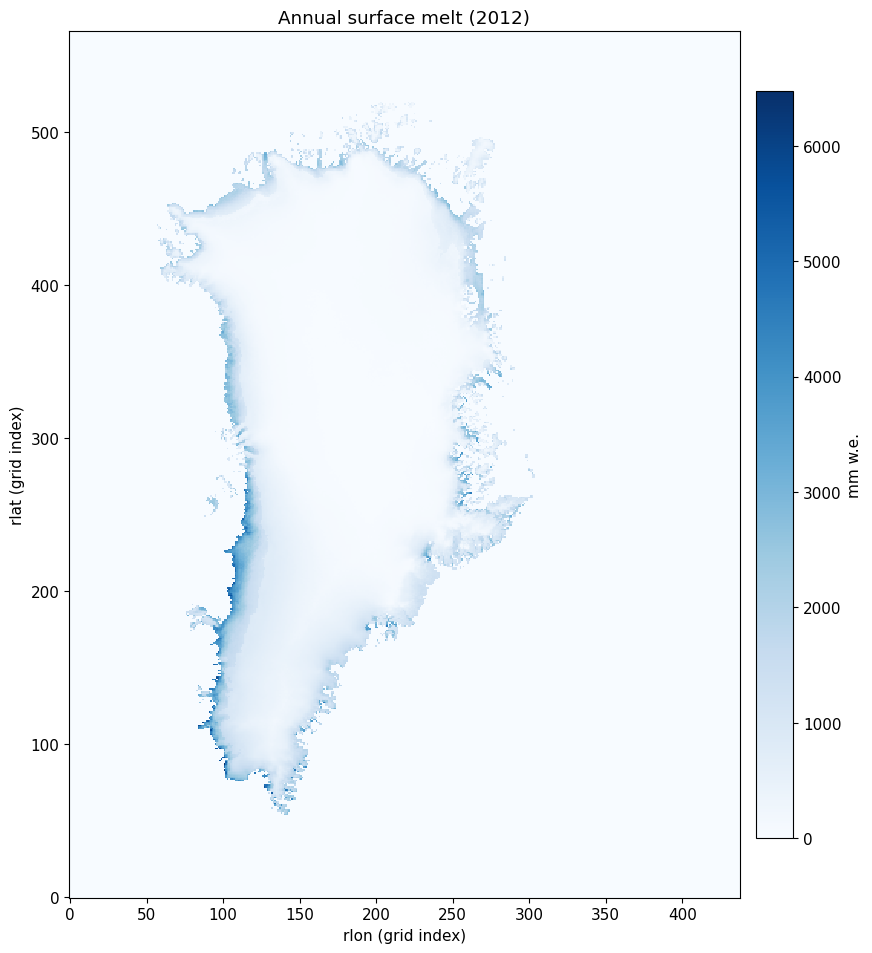

In [5]:
melt = load_annual('surfmelt', YEAR)

fig, ax = plt.subplots()
plot_annual_map(
    melt,
    title=f'Annual surface melt ({YEAR})',
    cmap='Blues',
    vmin=0,
    colorbar_label='mm w.e.',
    ax=ax,
)
plt.tight_layout()
plt.show()

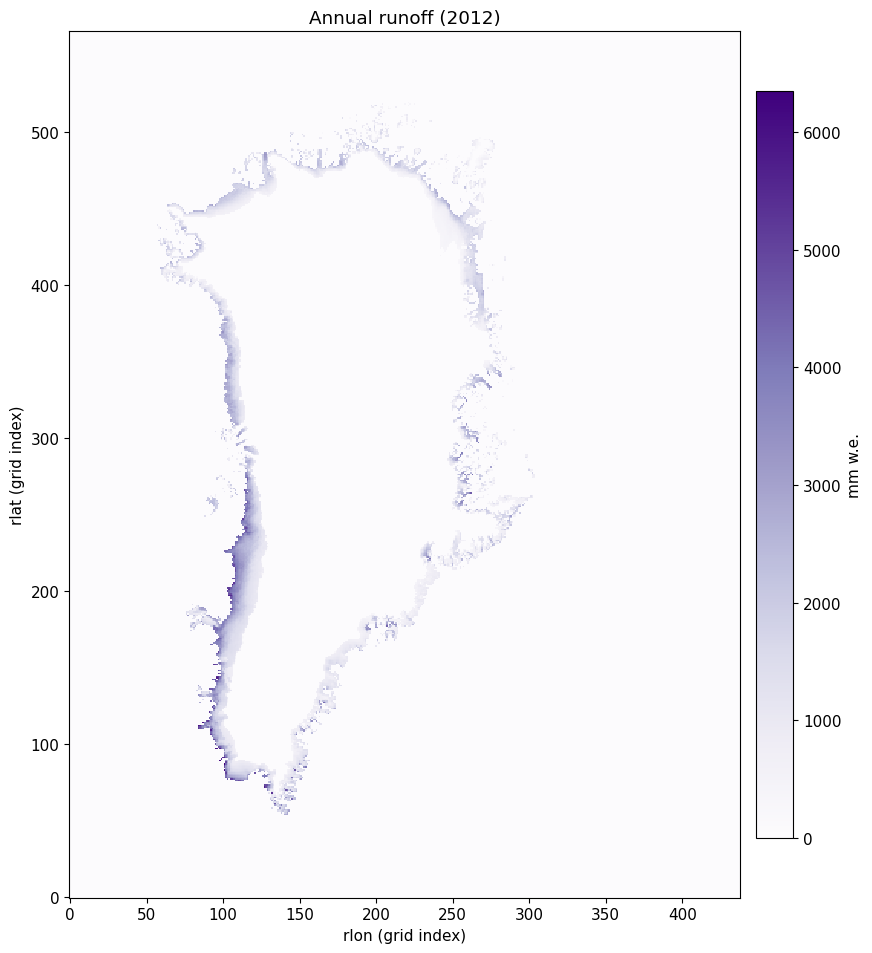

In [6]:
runoff = load_annual('Runoff', YEAR)

fig, ax = plt.subplots()
plot_annual_map(
    runoff,
    title=f'Annual runoff ({YEAR})',
    cmap='Purples',
    vmin=0,
    colorbar_label='mm w.e.',
    ax=ax,
)
plt.tight_layout()
plt.show()

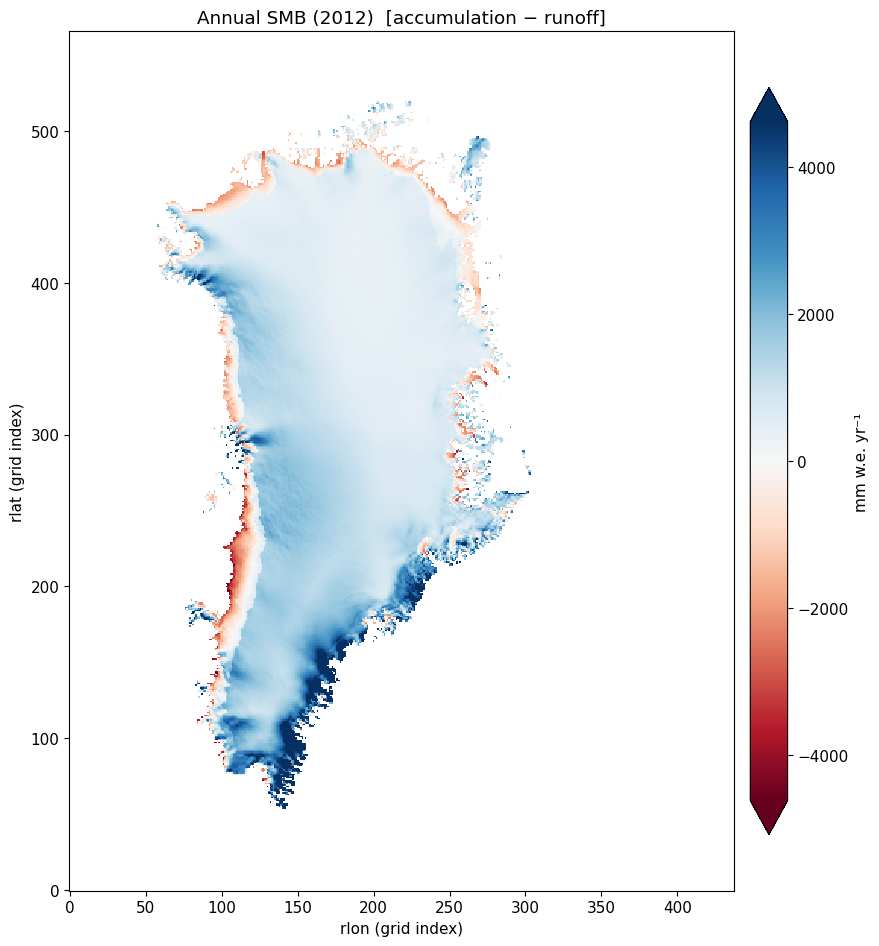

In [7]:
smb = compute_annual_smb(YEAR)

# Symmetric colour scale centred on zero
lim = float(np.nanpercentile(np.abs(smb.values), 98))

fig, ax = plt.subplots()
plot_annual_map(
    smb,
    title=f'Annual SMB ({YEAR})  [accumulation − runoff]',
    cmap='RdBu',
    vmin=-lim, vmax=lim,
    colorbar_label='mm w.e. yr⁻¹',
    ax=ax,
)
plt.tight_layout()
plt.show()

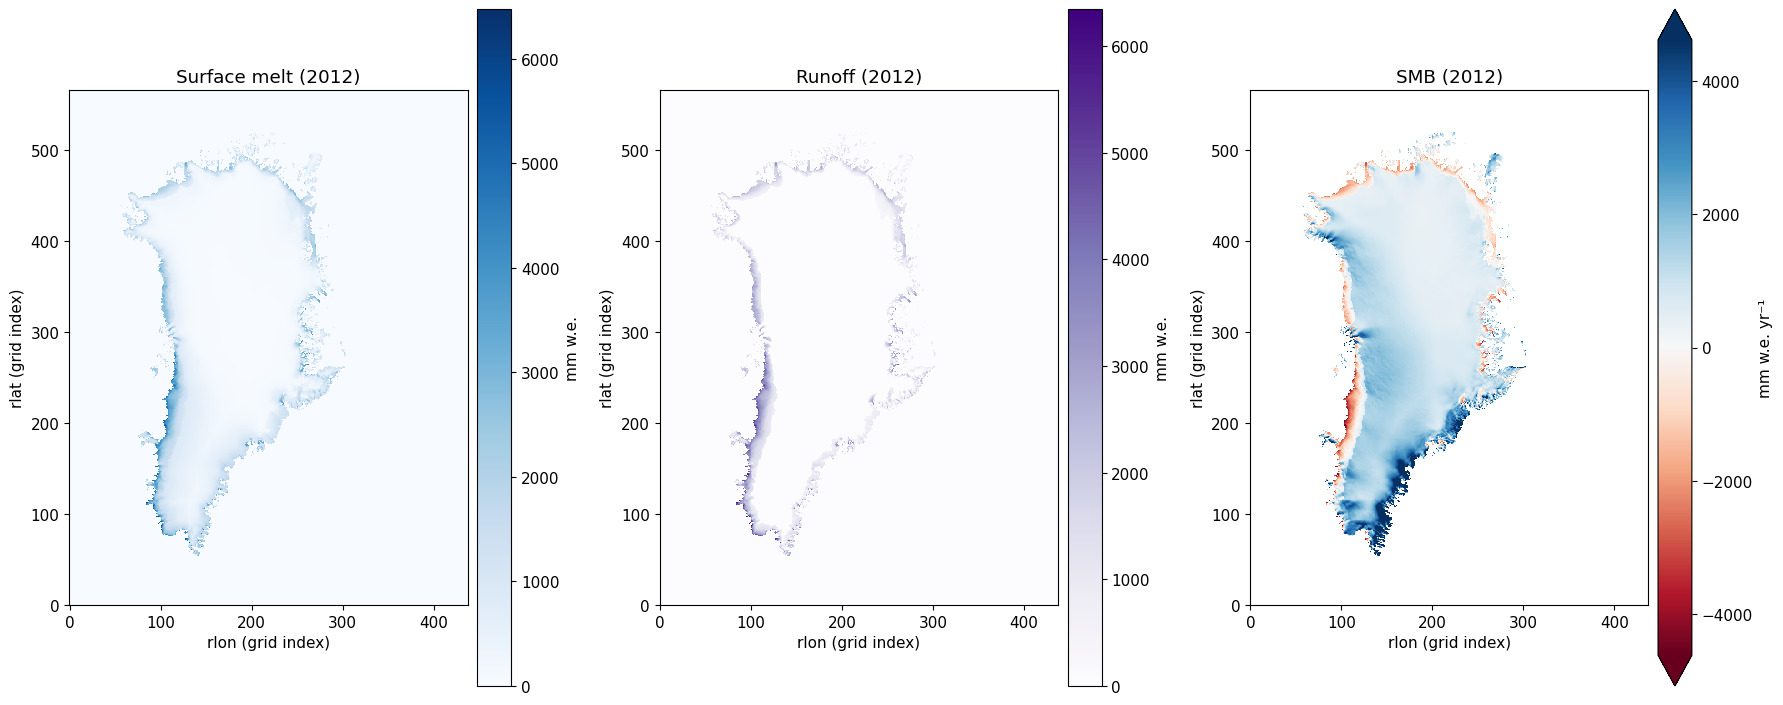

In [8]:
# Three-panel comparison for a single year
melt   = load_annual('surfmelt', YEAR)
runoff = load_annual('Runoff',   YEAR)
smb    = compute_annual_smb(YEAR)
lim    = float(np.nanpercentile(np.abs(smb.values), 98))

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
plot_annual_map(melt,   f'Surface melt ({YEAR})', 'Blues',   0, None, axes[0], 'mm w.e.')
plot_annual_map(runoff, f'Runoff ({YEAR})',        'Purples', 0, None, axes[1], 'mm w.e.')
plot_annual_map(smb,    f'SMB ({YEAR})',           'RdBu',    -lim, lim, axes[2], 'mm w.e. yr⁻¹')
plt.tight_layout()
plt.show()

---
## 3  Point time series

K-transect example locations (adjust rlat/rlon indices as needed).

In [9]:
# Grid indices for example points — update to your points of interest
POINTS = {
    'K-low  (~1494 m)': (56, 136),
    'K-mid  (~1542 m)': (58, 135),
    'K-high (~1590 m)': (60, 134),
}

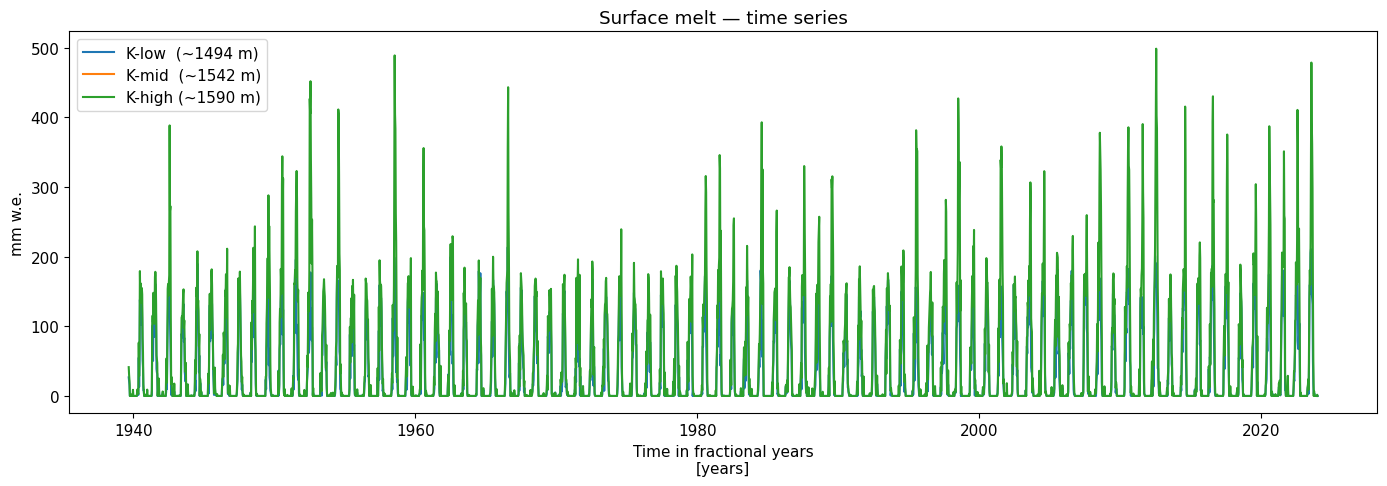

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

for label, (rlat, rlon) in POINTS.items():
    ts = load_timeseries('surfmelt', rlat, rlon)
    ts.plot(ax=ax, label=label, alpha=0.5)

ax.set_title('Surface melt — time series')
ax.set_ylabel('mm w.e.')
ax.legend()
plt.tight_layout()
plt.show()

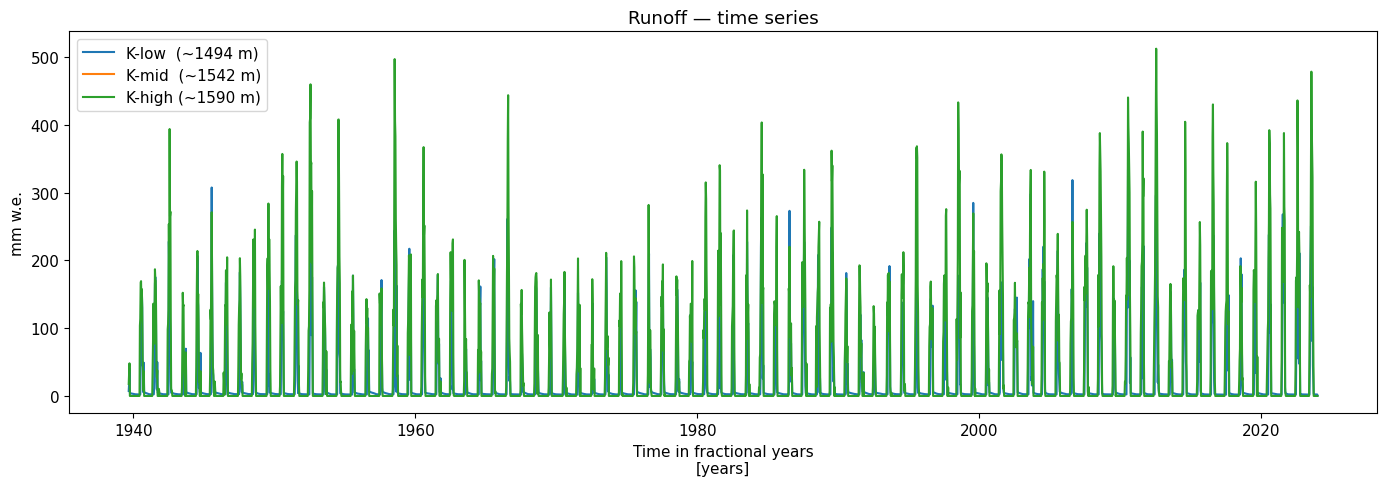

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

for label, (rlat, rlon) in POINTS.items():
    ts = load_timeseries('Runoff', rlat, rlon)
    ts.plot(ax=ax, label=label. alpha=0.5)

ax.set_title('Runoff — time series')
ax.set_ylabel('mm w.e.')
ax.legend()
plt.tight_layout()
plt.show()

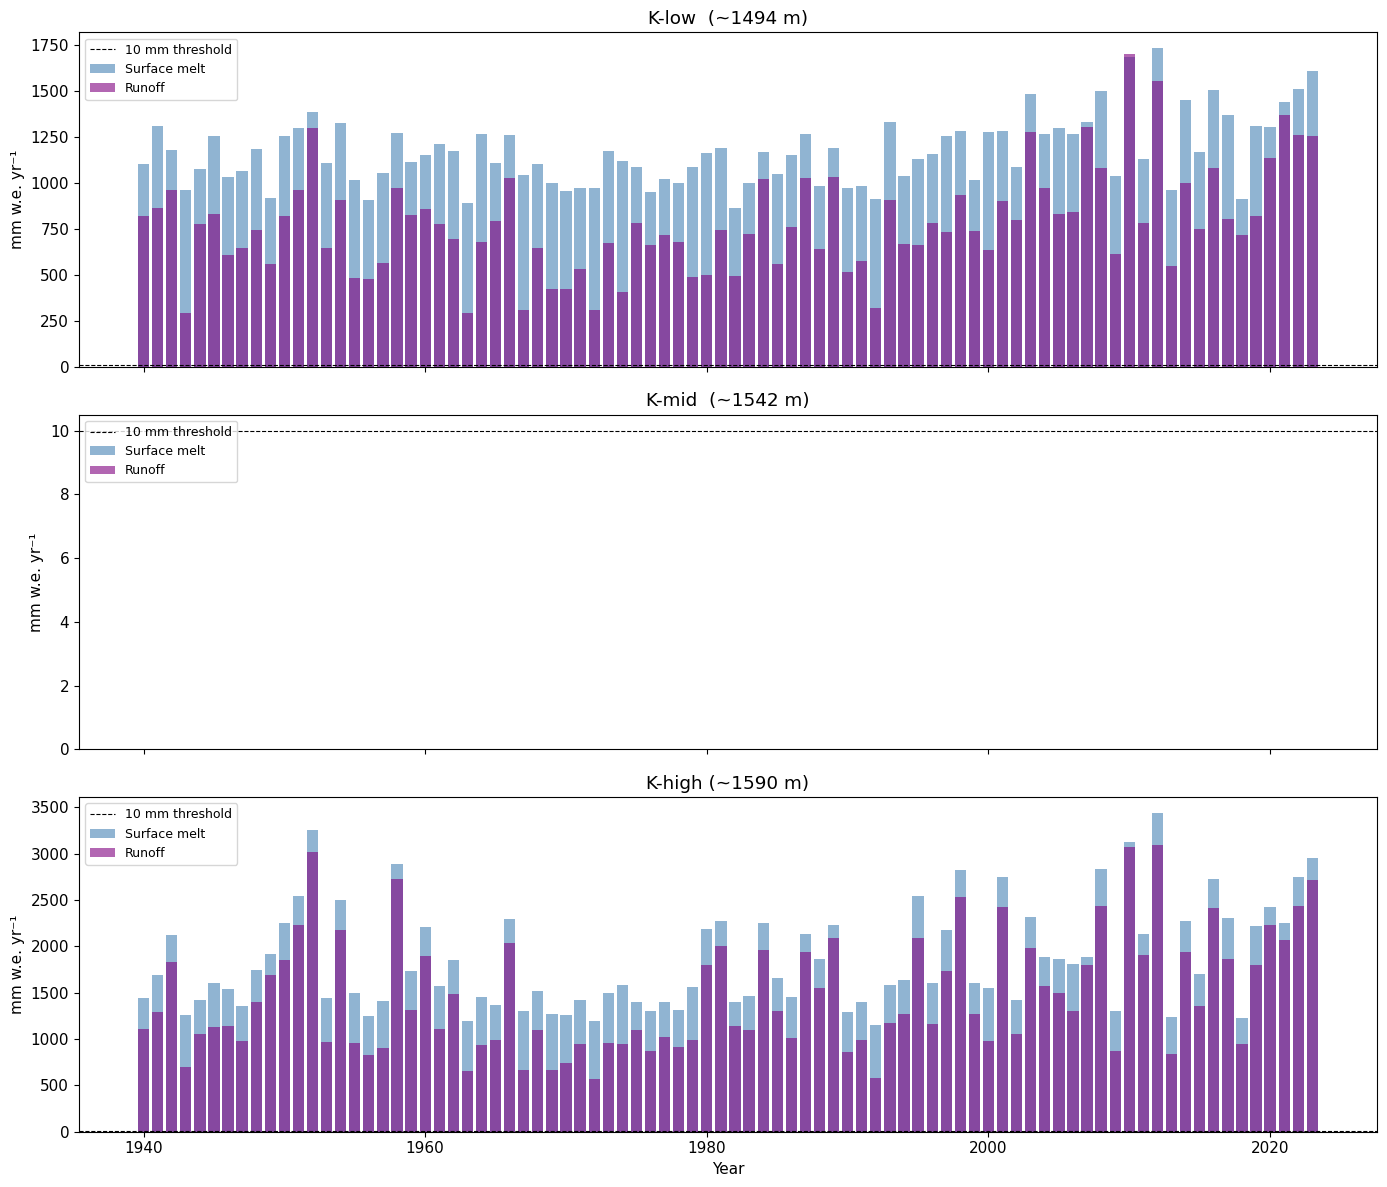

In [12]:
# Annual totals at each point — surfmelt and runoff on the same axes
years = np.arange(1940, 2024)

fig, axes = plt.subplots(len(POINTS), 1, figsize=(14, 4 * len(POINTS)), sharex=True)

for ax, (label, (rlat, rlon)) in zip(axes, POINTS.items()):
    melt_ts   = load_timeseries('surfmelt', rlat, rlon)
    runoff_ts = load_timeseries('Runoff',   rlat, rlon)

    ann_melt   = [float(melt_ts.sel(time=slice(y, y+1)).sum())   for y in years]
    ann_runoff = [float(runoff_ts.sel(time=slice(y, y+1)).sum()) for y in years]

    ax.bar(years, ann_melt,   label='Surface melt', alpha=0.6, color='steelblue')
    ax.bar(years, ann_runoff, label='Runoff',       alpha=0.6, color='purple')
    ax.axhline(10, color='k', linewidth=0.8, linestyle='--', label='10 mm threshold')
    ax.set_title(label)
    ax.set_ylabel('mm w.e. yr⁻¹')
    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

---
## 4  Zone transition maps

Each pixel is classified by whether it crossed the melt threshold between
year−1 and year:

| Category | Colour | Meaning |
|---|---|---|
| Dry (unchanged) | grey | melt ≤ threshold both years |
| Percolation (unchanged) | blue | melt > threshold both years |
| Dry → Percolation | green | below threshold last year, above this year |
| Percolation → Dry | red | above threshold last year, below this year |

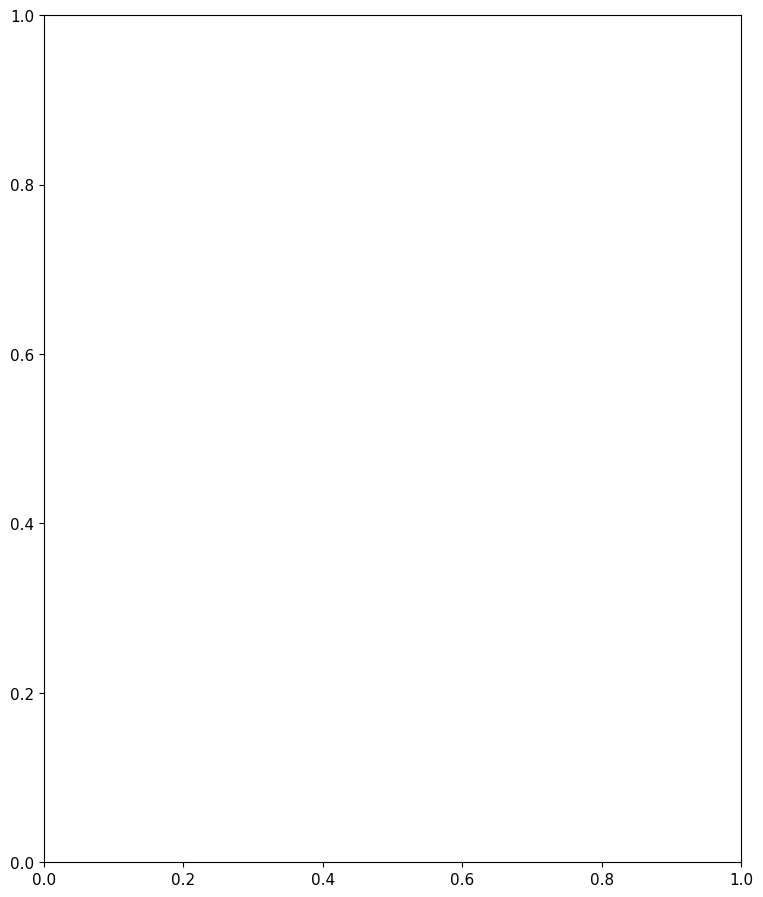

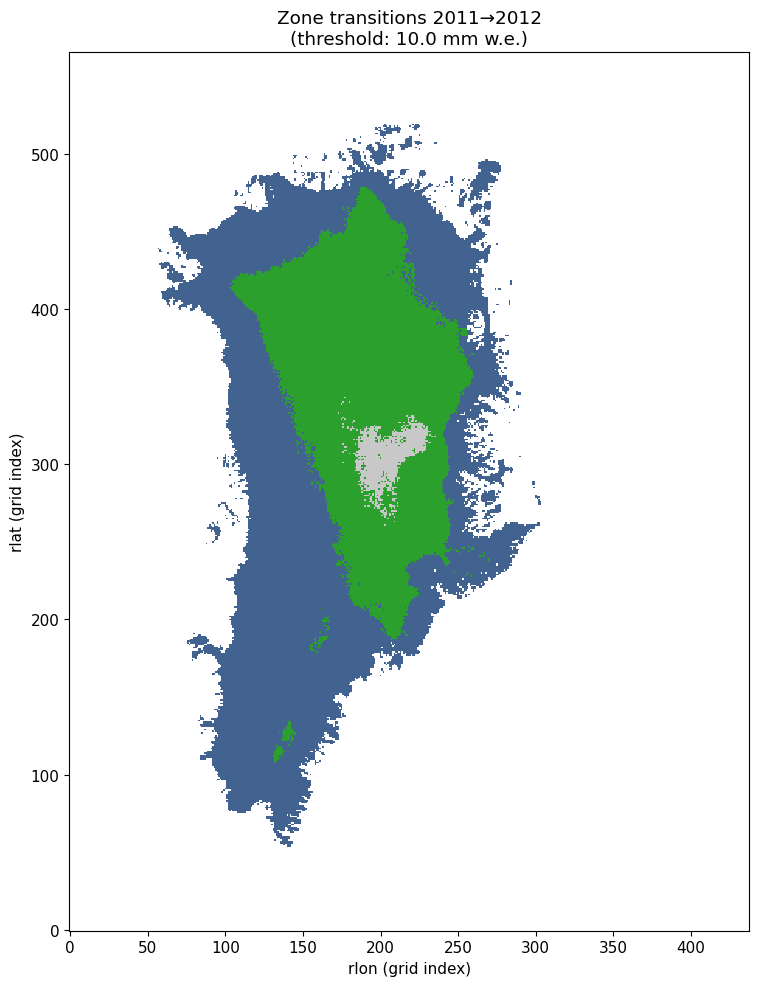

In [13]:
TRANS_YEAR      = 2012   # ← current year; compared against TRANS_YEAR - 1
MELT_THRESHOLD  = 10.0   # mm w.e.

fig, ax = plt.subplots()
plot_zone_transitions(TRANS_YEAR, melt_threshold=MELT_THRESHOLD)
plt.tight_layout()
plt.show()

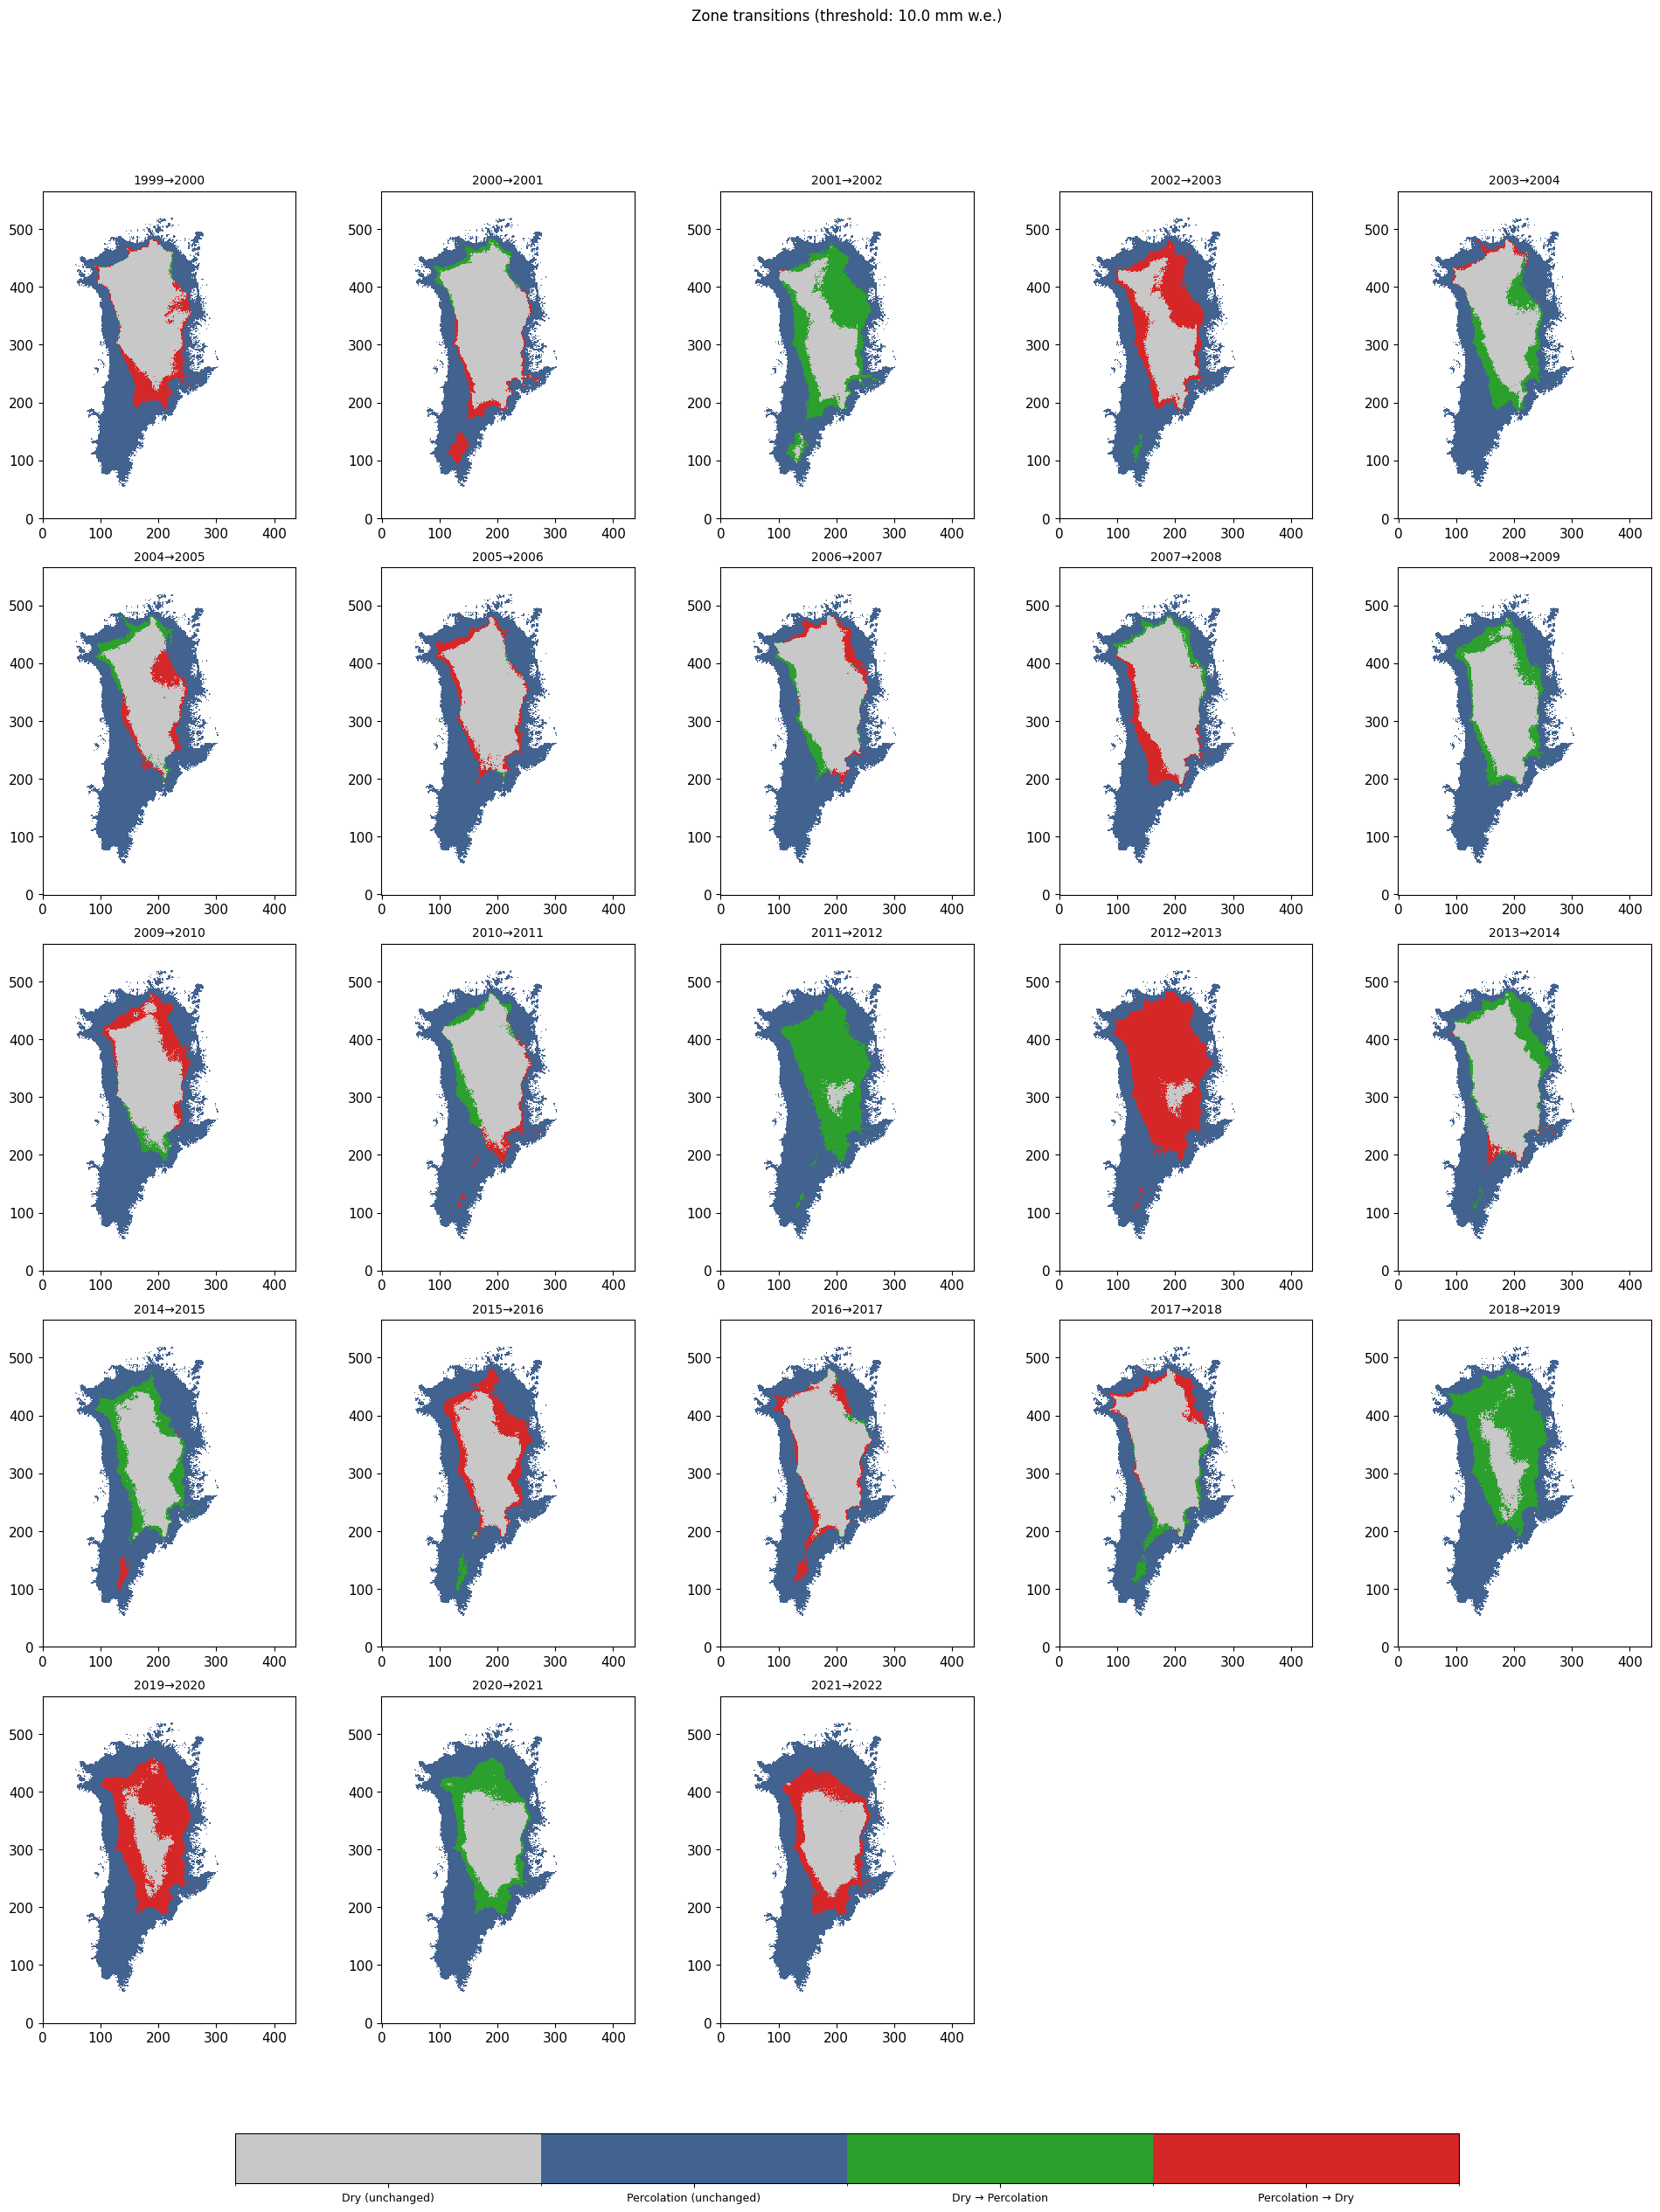

In [15]:
# Multi-year panel
TRANS_YEARS    = list(range(2000,2023,1))#[1995, 2000, 2005, 2010, 2012, 2019]
MELT_THRESHOLD = 10.0

fig, axes = plot_zone_transition_panel(
    TRANS_YEARS,
    melt_threshold=MELT_THRESHOLD,
    show_unchanged=True,
    ncols=5,
    title=f'Zone transitions (threshold: {MELT_THRESHOLD} mm w.e.)',
)
plt.show()

In [ ]:
# Plot integrated ice content

In [ ]:
ds = xr.open_dataset("/home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_icemass_FGRN055_1939-2023_10day.nc", decode_times=False)

ds